In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import models, layers

2026-03-06 06:55:03.147040: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-06 06:55:03.147083: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-06 06:55:03.148437: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-06 06:55:03.155230: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Task
Train and evaluate a deep learning model for classifying AI-generated versus human-created art using the "ai-art-vs-human-art" Kaggle dataset, reporting the training process, achieved accuracy, and insights.

In [2]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [3]:
import os
os.listdir("dataset")

['Art']

In [4]:
import os
os.listdir("archive/Art")

['RealArt', 'AiArtData']

In [5]:
import os

print(len(os.listdir("archive/Art/RealArt")))
print(len(os.listdir("archive/Art/AiArtData")))

436
539


In [6]:
dataset = tf.keras.utils.image_dataset_from_directory(
    "archive/Art",
    image_size=(224, 224),
    batch_size=32
)

Found 971 files belonging to 2 classes.


2026-03-06 06:55:12.394814: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-06 06:55:12.402700: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-06 06:55:12.403225: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [7]:
img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "archive/Art",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "archive/Art",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

Found 971 files belonging to 2 classes.
Using 777 files for training.
Found 971 files belonging to 2 classes.
Using 194 files for validation.


In [8]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [9]:

# Load MobileNetV2 without the top classification layer
base_model = MobileNetV2(input_shape=(224,224,3),
                         include_top=False,
                         weights='imagenet')

# Freeze all base layers
base_model.trainable = False

In [10]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # binary classification
])

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 2422081 (9.24 MB)
Trainable params: 164097 (641.00 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5  
)

Epoch 1/5


2026-03-06 07:01:28.300878: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


25/25 [==============================] - 3s 84ms/step - loss: 0.0067 - accuracy: 1.0000 - val_loss: 0.7813 - val_accuracy: 0.7680
Epoch 2/5


2026-03-06 07:01:31.312566: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


25/25 [==============================] - 3s 83ms/step - loss: 0.0058 - accuracy: 1.0000 - val_loss: 0.7923 - val_accuracy: 0.7629
Epoch 3/5


...

25/25 [==============================] - 3s 82ms/step - loss: 0.0051 - accuracy: 1.0000 - val_loss: 0.8091 - val_accuracy: 0.7680
Epoch 4/5


2026-03-06 07:01:37.276503: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


25/25 [==============================] - 3s 82ms/step - loss: 0.0045 - accuracy: 1.0000 - val_loss: 0.8218 - val_accuracy: 0.7577
Epoch 5/5


2026-03-06 07:01:40.272794: W tensorflow/core/lib/png/png_io.cc:88] PNG warning: iCCP: profile 'ICC Profile': 'CMYK': invalid ICC profile color space


25/25 [==============================] - 3s 82ms/step - loss: 0.0039 - accuracy: 1.0000 - val_loss: 0.8365 - val_accuracy: 0.7629


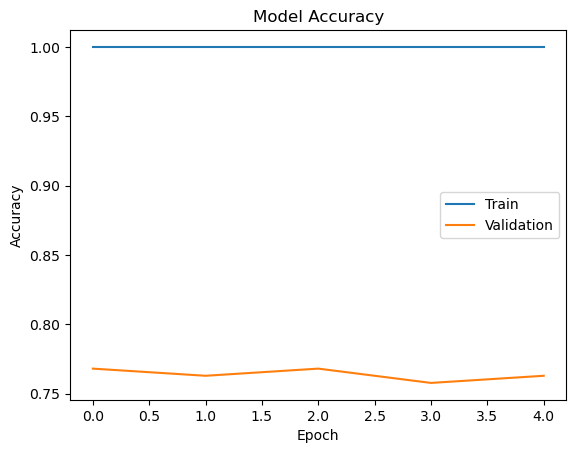

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

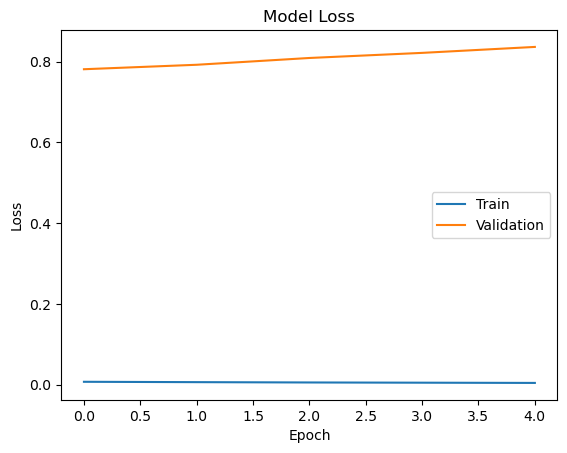

In [21]:
plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()